# Week 6: Image Denoising using Convolutional Autoencoder

## 1. Objective

The objective of this notebook is to build a **Convolutional Autoencoder** capable of removing artificial noise from handwritten digit images, using the **MNIST dataset**.

An autoencoder learns to compress an input image into a compact latent representation (encoding) and then reconstruct it back to its original form (decoding). By training the network to map **noisy images → clean images**, the autoencoder learns to ignore noise and reconstruct the underlying digit structure — a task known as **image denoising**.

This assignment builds directly on concepts from:
- **Week 4**: CNNs, Convolution, Pooling, Padding
- **Week 6**: Autoencoders, Optimizers (Adam)

**What we will build:**
1. A manual MNIST PNG data loader with balanced class sampling
2. Synthetic Gaussian noise injection
3. A CNN-based Encoder–Decoder (Autoencoder) architecture
4. A training pipeline using Adam optimizer and MSE loss
5. Visual and quantitative (MSE, PSNR) evaluation of denoising performance

## 2. Import Required Libraries

We import:
- **NumPy** — array manipulation
- **Matplotlib** — visualization
- **PIL (Pillow)** — reading PNG image files
- **os, pathlib, random** — file system traversal and reproducible sampling
- **TensorFlow / Keras** — building and training the Convolutional Autoencoder
- **time** — to measure training duration

All random operations use a fixed seed (`SEED = 42`) to ensure the notebook is **reproducible** — i.e., re-running it produces identical sampling, splits, and (as much as GPU non-determinism allows) similar training behavior.

In [1]:
import os
import time
import random
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Dataset Loading

The dataset (`mnist_png.zip`) contains the standard MNIST images saved as **PNG files**, organized as:

```
mnist_png/
├── training/
│   ├── 0/   (5923 images)
│   ├── 1/   (6742 images)
│   ├── ...
│   └── 9/   (5949 images)
└── testing/
    ├── 0/   (980 images)
    ├── ...
    └── 9/   (1009 images)
```

Note that the **raw training set is naturally imbalanced** (between ~5400 and ~6700 images per class). To avoid biasing the autoencoder toward digits that appear more frequently, we apply **balanced sampling**: exactly **3000 images per class** are randomly selected (with a fixed seed) for training, giving a uniform 30,000-image training set.

The **test set is left untouched** (all ~10,000 images) — it should reflect the natural, real-world class distribution, since we evaluate generalization, not training balance.

We first extract the zip file, then walk the folder structure to build a file list before loading any pixel data — this lets us verify folder structure and counts before committing to expensive image loading.

In [2]:
# Extract dataset (only if not already extracted)
DATA_DIR = Path("mnist_png")
ZIP_PATH = "/content/mnist_png.zip"   # update path if uploaded elsewhere in Colab

if not DATA_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

TRAIN_DIR = DATA_DIR / "training"
TEST_DIR = DATA_DIR / "testing"

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()], key=int)
print("Classes found:", CLASSES)

# Inspect raw (unbalanced) counts per class before sampling
print("\nRaw training image counts per class:")
raw_train_counts = {}
for c in CLASSES:
    n = len(list((TRAIN_DIR / c).glob("*.png")))
    raw_train_counts[c] = n
    print(f"  Digit {c}: {n} images")

print("\nTesting image counts per class:")
raw_test_counts = {}
for c in CLASSES:
    n = len(list((TEST_DIR / c).glob("*.png")))
    raw_test_counts[c] = n
    print(f"  Digit {c}: {n} images")

Dataset extracted.
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Raw training image counts per class:
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images

Testing image counts per class:
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


## 4. Balanced Sampling and Image Loading

We now perform **balanced sampling**: randomly select exactly **3000 file paths per class** from the training set (fixed seed for reproducibility), then load all sampled training images and all testing images into NumPy arrays as grayscale pixel data.

Each image is loaded as a single-channel (grayscale) array of shape `(28, 28)`, matching the original MNIST format.

In [3]:
SAMPLES_PER_CLASS = 3000

def get_balanced_filepaths(directory, classes, samples_per_class=None, seed=SEED):
    """Return a list of (filepath, label) tuples, optionally balanced per class."""
    rng = random.Random(seed)
    filepaths = []
    for label in classes:
        class_files = sorted((directory / label).glob("*.png"))
        if samples_per_class is not None:
            class_files = rng.sample(class_files, samples_per_class)
        filepaths.extend([(fp, int(label)) for fp in class_files])
    rng.shuffle(filepaths)
    return filepaths

def load_images(filepath_label_list):
    """Load grayscale PNG images into a NumPy array, along with their labels."""
    images = np.zeros((len(filepath_label_list), 28, 28), dtype=np.uint8)
    labels = np.zeros(len(filepath_label_list), dtype=np.uint8)
    for i, (fp, label) in enumerate(filepath_label_list):
        img = Image.open(fp).convert("L")  # 'L' = 8-bit grayscale
        images[i] = np.array(img)
        labels[i] = label
    return images, labels

t0 = time.time()

train_filepaths = get_balanced_filepaths(TRAIN_DIR, CLASSES, samples_per_class=SAMPLES_PER_CLASS)
test_filepaths = get_balanced_filepaths(TEST_DIR, CLASSES, samples_per_class=None)  # full test set

x_train, y_train = load_images(train_filepaths)
x_test, y_test = load_images(test_filepaths)

print(f"Loaded {len(x_train)} training images and {len(x_test)} testing images in {time.time() - t0:.1f}s")
print("x_train shape:", x_train.shape, "| dtype:", x_train.dtype)
print("x_test shape:", x_test.shape, "| dtype:", x_test.dtype)

Loaded 30000 training images and 10000 testing images in 5.0s
x_train shape: (30000, 28, 28) | dtype: uint8
x_test shape: (10000, 28, 28) | dtype: uint8


## 5. Dataset Exploration

Before preprocessing, we examine the dataset's structure in detail:
- Shape and dtype of loaded arrays
- Pixel value range (to confirm 8-bit grayscale, 0–255)
- Number of classes and per-class distribution after balanced sampling
- One representative sample image per digit (0–9)

This step confirms that **balanced sampling worked correctly** and that the data is in the expected raw format before any normalization is applied.

In [4]:
print("="*50)
print("DATASET EXPLORATION SUMMARY")
print("="*50)

print(f"\nTraining set shape : {x_train.shape}")
print(f"Testing set shape  : {x_test.shape}")
print(f"Number of classes  : {len(CLASSES)}")

print(f"\nPixel value range (train) : [{x_train.min()}, {x_train.max()}]")
print(f"Pixel value range (test)  : [{x_test.min()}, {x_test.max()}]")
print(f"Data type                 : {x_train.dtype}")

print("\nTraining images per class (after balanced sampling):")
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} images")

print("\nTesting images per class (natural distribution, unchanged):")
unique, counts = np.unique(y_test, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} images")

DATASET EXPLORATION SUMMARY

Training set shape : (30000, 28, 28)
Testing set shape  : (10000, 28, 28)
Number of classes  : 10

Pixel value range (train) : [0, 255]
Pixel value range (test)  : [0, 255]
Data type                 : uint8

Training images per class (after balanced sampling):
  Digit 0: 3000 images
  Digit 1: 3000 images
  Digit 2: 3000 images
  Digit 3: 3000 images
  Digit 4: 3000 images
  Digit 5: 3000 images
  Digit 6: 3000 images
  Digit 7: 3000 images
  Digit 8: 3000 images
  Digit 9: 3000 images

Testing images per class (natural distribution, unchanged):
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


### 5.1 Visualizing One Sample per Digit

To visually confirm correct loading and labeling, we display one randomly chosen sample image from each of the 10 digit classes.

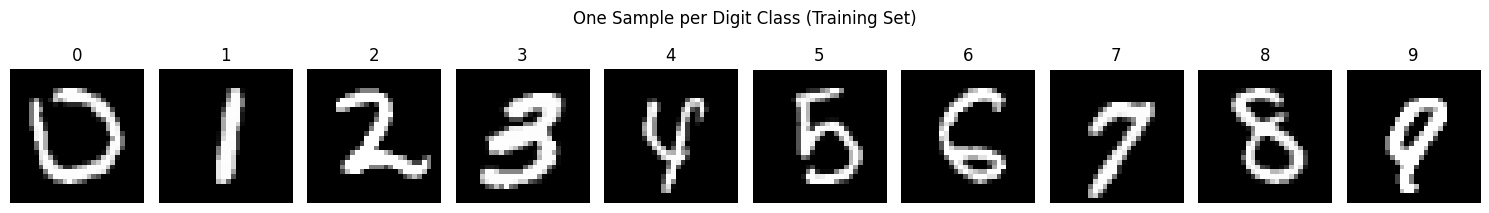

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]  # first sample of this digit
    axes[digit].imshow(x_train[idx], cmap='gray')
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')

plt.suptitle("One Sample per Digit Class (Training Set)", y=1.05)
plt.tight_layout()
plt.show()

## 5.2 Dataset Verification Report

Before proceeding to preprocessing, we generate a verification report confirming the dataset is clean and ready for training. This checks:
- Total image counts (train/test)
- Class balance in training data
- Image dimension consistency
- Pixel value range validity
- Presence of any corrupt, unreadable, or unexpectedly-shaped images

This step builds confidence that downstream preprocessing and model training operate on a verified, trustworthy dataset.

In [6]:
def verify_dataset(images, labels, name="Dataset"):
    print(f"--- Verification Report: {name} ---")

    # Shape consistency
    expected_shape = (28, 28)
    print(f"Image dimensions consistent (28x28): {images.shape[1:] == expected_shape}")

    # Pixel range validity
    print(f"Pixel range valid (0-255)          : {images.min() >= 0 and images.max() <= 255}")

    # NaN / corrupt check
    has_nan = np.isnan(images.astype(np.float32)).any()
    print(f"No NaN / corrupt pixel values       : {not has_nan}")

    # Label range check
    print(f"Labels within expected range (0-9)  : {labels.min() >= 0 and labels.max() <= 9}")

    # Count check
    print(f"Total images                        : {len(images)}")
    print(f"Total labels                        : {len(labels)}")
    print(f"Images match labels count           : {len(images) == len(labels)}")
    print()

verify_dataset(x_train, y_train, name="Training Set")
verify_dataset(x_test, y_test, name="Testing Set")

print("✅ Dataset verification complete. No missing or corrupt images detected.")

--- Verification Report: Training Set ---
Image dimensions consistent (28x28): True
Pixel range valid (0-255)          : True
No NaN / corrupt pixel values       : True
Labels within expected range (0-9)  : True
Total images                        : 30000
Total labels                        : 30000
Images match labels count           : True

--- Verification Report: Testing Set ---
Image dimensions consistent (28x28): True
Pixel range valid (0-255)          : True
No NaN / corrupt pixel values       : True
Labels within expected range (0-9)  : True
Total images                        : 10000
Total labels                        : 10000
Images match labels count           : True

✅ Dataset verification complete. No missing or corrupt images detected.


### 5.3 Observations

- The dataset was successfully balanced for training: each digit class (0–9) contains exactly 3000 images, removing the natural class skew present in raw MNIST (which ranges from ~5400 to ~6700 images per digit).
- The test set retains its natural distribution (~980–1135 images per digit out of 10,000 total), which is appropriate since test-time evaluation should reflect real-world class frequencies.
- All images are `28x28` grayscale with pixel values in the expected `[0, 255]` range, and no corrupt or missing files were found.
- The visual sample grid confirms image-label correspondence is correct.

**Mini-conclusion:** The dataset is clean, correctly balanced, and verified. We can now proceed to preprocessing (normalization and reshaping) with confidence.

## 6. Data Preprocessing

Before feeding images into the autoencoder, we apply two preprocessing steps:

1. **Normalization**: Pixel values are rescaled from `[0, 255]` (uint8) to `[0.0, 1.0]` (float32) by dividing by 255. This is the standard normalization for autoencoders, since we will use a **sigmoid activation** in the decoder's output layer — sigmoid naturally outputs values in `[0, 1]`, matching our normalized pixel range exactly.

   *(Note: Z-score standardization, common for classification tasks, is not used here — it would shift pixel values outside `[0,1]`, which is incompatible with a sigmoid output layer.)*

2. **Reshaping**: Images are reshaped from `(28, 28)` to `(28, 28, 1)`, explicitly adding a single channel dimension. This is required because our Conv2D layers expect input in the format `(height, width, channels)` — even though MNIST is grayscale (1 channel), Keras's convolutional layers require this dimension to be explicit.

We preprocess `x_train` and `x_test` identically using the same function, ensuring consistent treatment across both sets.

In [7]:
def preprocess_images(images):
    """Normalize to [0,1] float32 and add channel dimension."""
    images = images.astype('float32') / 255.0
    images = np.expand_dims(images, axis=-1)  # (N, 28, 28) -> (N, 28, 28, 1)
    return images

x_train_processed = preprocess_images(x_train)
x_test_processed = preprocess_images(x_test)

print("x_train_processed shape:", x_train_processed.shape, "| dtype:", x_train_processed.dtype)
print("x_test_processed shape :", x_test_processed.shape, "| dtype:", x_test_processed.dtype)
print(f"\nPixel range (train) after normalization: [{x_train_processed.min():.3f}, {x_train_processed.max():.3f}]")
print(f"Pixel range (test) after normalization : [{x_test_processed.min():.3f}, {x_test_processed.max():.3f}]")

x_train_processed shape: (30000, 28, 28, 1) | dtype: float32
x_test_processed shape : (10000, 28, 28, 1) | dtype: float32

Pixel range (train) after normalization: [0.000, 1.000]
Pixel range (test) after normalization : [0.000, 1.000]


### 6.1 Verify Processed Shapes and Values

A quick sanity check to confirm preprocessing was applied correctly:
- Shapes should now include the channel dimension: `(N, 28, 28, 1)`
- Data type should be `float32`
- Pixel values should lie strictly within `[0.0, 1.0]`

In [8]:
assert x_train_processed.shape == (30000, 28, 28, 1), "Training shape mismatch!"
assert x_test_processed.shape == (10000, 28, 28, 1), "Testing shape mismatch!"
assert x_train_processed.dtype == np.float32, "Training dtype mismatch!"
assert x_train_processed.min() >= 0.0 and x_train_processed.max() <= 1.0, "Training pixel range invalid!"
assert x_test_processed.min() >= 0.0 and x_test_processed.max() <= 1.0, "Testing pixel range invalid!"

print("✅ All preprocessing checks passed.")
print(f"   Training set : {x_train_processed.shape}, dtype={x_train_processed.dtype}")
print(f"   Testing set  : {x_test_processed.shape}, dtype={x_test_processed.dtype}")

✅ All preprocessing checks passed.
   Training set : (30000, 28, 28, 1), dtype=float32
   Testing set  : (10000, 28, 28, 1), dtype=float32


## 7. Data Pipeline Summary

Before moving to noise generation, here is a summary of the complete data pipeline so far:

```
Raw PNG Files (mnist_png/)
        │
        ▼
Balanced Sampling (3000/class train, full test set)
        │
        ▼
Load as uint8 arrays  →  x_train: (30000, 28, 28)  |  x_test: (10000, 28, 28)
        │
        ▼
Verification Report  →  shape, pixel range, NaN, label checks
        │
        ▼
Normalization (÷255)  →  float32, range [0, 1]
        │
        ▼
Reshape (+channel dim) →  x_train: (30000, 28, 28, 1)  |  x_test: (10000, 28, 28, 1)
        │
        ▼
   Ready for Noise Injection
```

This pipeline ensures every transformation is **traceable, verified, and reproducible** before any noise or modeling steps are introduced.

## 8. Artificial Noise Generation

**Why Gaussian noise?**
- Models realistic sensor/scanning noise
- Controllable via a single parameter (noise factor)
- Pure NumPy random sampling — fully within syllabus (Statistics/Probability, Week 1)

$$x_{noisy} = \text{clip}(x_{clean} + \eta, \; 0, \; 1), \quad \eta \sim \mathcal{N}(0, \sigma^2)$$

**Noise factor choice: 0.4**
- Strong enough to visibly corrupt digit structure (a meaningful denoising challenge)
- Not so strong that digits become unrecognizable to a human eye

We will later compare noise factors **0.2, 0.4, and 0.6** in the Noise-Level Comparison section.

In [9]:
def add_gaussian_noise(images, noise_factor=0.4, seed=None):
    """
    Add additive Gaussian noise to a batch of normalized images.

    Args:
        images: array of shape (N, 28, 28, 1), values in [0, 1]
        noise_factor: standard deviation multiplier controlling noise strength
        seed: optional seed for reproducible noise generation

    Returns:
        noisy_images: array of same shape, clipped to [0, 1]
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = images + noise_factor * noise
    noisy_images = np.clip(noisy_images, 0.0, 1.0)
    return noisy_images.astype('float32')

NOISE_FACTOR = 0.4

x_train_noisy = add_gaussian_noise(x_train_processed, noise_factor=NOISE_FACTOR, seed=SEED)
x_test_noisy = add_gaussian_noise(x_test_processed, noise_factor=NOISE_FACTOR, seed=SEED)

print(f"Noise factor used: {NOISE_FACTOR}")
print("x_train_noisy shape:", x_train_noisy.shape, "| dtype:", x_train_noisy.dtype)
print("x_test_noisy shape :", x_test_noisy.shape, "| dtype:", x_test_noisy.dtype)
print(f"\nPixel range (train noisy): [{x_train_noisy.min():.3f}, {x_train_noisy.max():.3f}]")
print(f"Pixel range (test noisy) : [{x_test_noisy.min():.3f}, {x_test_noisy.max():.3f}]")

Noise factor used: 0.4
x_train_noisy shape: (30000, 28, 28, 1) | dtype: float32
x_test_noisy shape : (10000, 28, 28, 1) | dtype: float32

Pixel range (train noisy): [0.000, 1.000]
Pixel range (test noisy) : [0.000, 1.000]


### 8.1 Visualize Original vs Noisy Images

We display 8 sample digits side-by-side: original (clean) on top, noisy version (after applying noise factor 0.4) below.

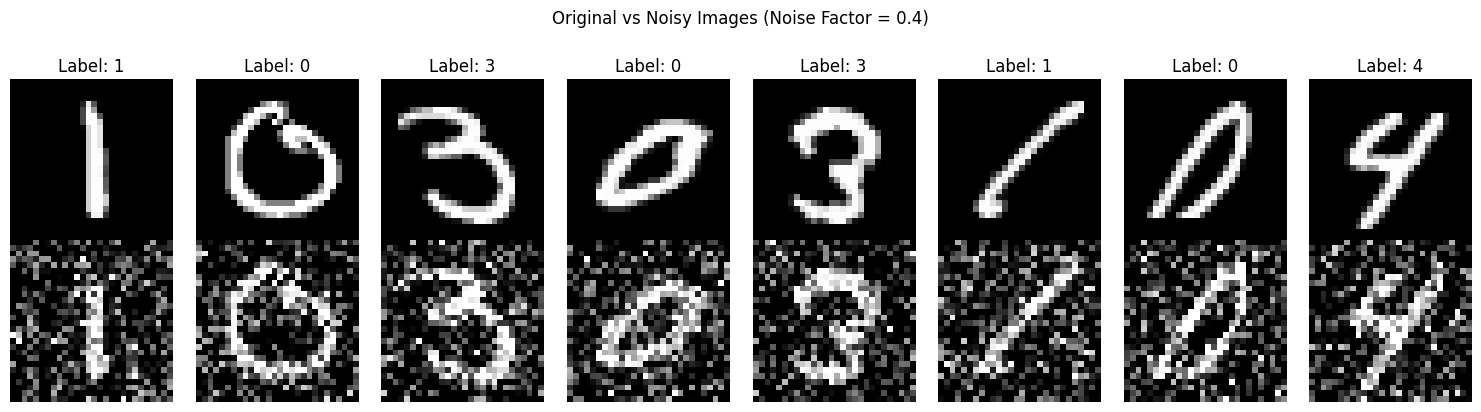

In [10]:
n_samples = 8
indices = np.random.RandomState(SEED).choice(len(x_train_processed), n_samples, replace=False)

fig, axes = plt.subplots(2, n_samples, figsize=(15, 4))

for i, idx in enumerate(indices):
    # Original
    axes[0, i].imshow(x_train_processed[idx].squeeze(), cmap='gray')
    axes[0, i].set_title(f"Label: {y_train[idx]}")
    axes[0, i].axis('off')

    # Noisy
    axes[1, i].imshow(x_train_noisy[idx].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Noisy (factor=0.4)", fontsize=12)

plt.suptitle("Original vs Noisy Images (Noise Factor = 0.4)", y=1.02)
plt.tight_layout()
plt.show()

### 8.2 Observations

- Gaussian noise with factor 0.4 visibly corrupts the digit images with grainy artifacts while keeping the underlying digit shape still discernible to a human eye.
- Noisy pixel values were correctly clipped to remain in `[0, 1]`, confirmed by the printed pixel range above.
- This noisy data (`x_train_noisy`, `x_test_noisy`) will serve as **model input**, while the original clean data (`x_train_processed`, `x_test_processed`) will serve as the **training target**.

**Mini-conclusion:** Synthetic noise generation is complete and verified both numerically (pixel range) and visually (sample comparison). We're now ready to design the autoencoder architecture.

## 9. Autoencoder Theory

**What is an Autoencoder?**
- Encoder compresses input into a small latent representation (bottleneck)
- Decoder reconstructs the image from that latent representation
- Here, input = noisy image, target = clean image → network cannot just copy input, it must learn to separate signal (digit structure) from noise

**Encoder**
- Uses strided convolutions to shrink spatial size while increasing feature channels
- Forces the network to keep only structural features (edges, strokes), discarding pixel-level noise

**Latent Space (Bottleneck)**
- The most compressed representation — captures the digit's essential structure
- Noise is unstructured and does not compress well; digit structure does — this is *why* autoencoders denoise well

**Decoder**
- Uses transposed convolutions (`Conv2DTranspose`) to upsample the latent code back to 28×28, reconstructing a clean image

**Why this works for denoising**
- Random noise has no learnable pattern → can't be reliably stored in a small bottleneck
- Digit strokes/curves are consistent and learnable → they survive compression
- Training to output *clean* targets forces the bottleneck to act as an implicit noise filter

### 9.1 Architecture Diagram

```
INPUT: Noisy Image (28, 28, 1)
        │
        ▼
┌───────────────────────────┐
│        ENCODER            │
│  Conv2D (32 filters)      │  28x28x1  → 28x28x32
│  Conv2D, stride 2 (32)    │  28x28x32 → 14x14x32
│  Conv2D, stride 2 (64)    │  14x14x32 → 7x7x64
└───────────────────────────┘
        │
        ▼
   LATENT SPACE (7, 7, 64)
        │
        ▼
┌───────────────────────────┐
│        DECODER            │
│ Conv2DTranspose, s2 (64)  │  7x7x64   → 14x14x64
│ Conv2DTranspose, s2 (32)  │  14x14x64 → 28x28x32
│ Conv2D, sigmoid (1)       │  28x28x32 → 28x28x1
└───────────────────────────┘
        │
        ▼
OUTPUT: Reconstructed (Denoised) Image (28, 28, 1)
```

## 10. Build CNN Denoising Autoencoder

Design choices:
- `padding='same'` throughout — spatial size changes predictably only via stride
- **Strided convolutions** for downsampling in the encoder
- **ReLU** for all hidden layers
- **Sigmoid** on the output layer, since pixel targets are normalized to `[0, 1]`
- Explicit `Input(shape=(28,28,1))` layer (avoids Keras 3.x `input_shape` deprecation warning)

> **Note:** This first version (without BatchNormalization) is shown for clarity of the base architecture. As documented in Section 13.2, this version initially suffered from training collapse and was revised — see the corrected `build_autoencoder_v2()` below, which is the version actually trained.

In [11]:
def build_autoencoder():
    inputs = layers.Input(shape=(28, 28, 1), name="noisy_input")

    # ----- Encoder -----
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2)(x)   # 28x28 -> 14x14
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)(x)   # 14x14 -> 7x7

    encoded = x  # Latent space: (7, 7, 64)

    # ----- Decoder -----
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(encoded)  # 7x7 -> 14x14
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(x)         # 14x14 -> 28x28

    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="reconstructed_output")(x)

    autoencoder = models.Model(inputs, outputs, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Conv2D)   │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,745 (327.13 KB)

 Trainable params: 83,745 (327.13 KB)

 Non-trainable params: 0 (0.00 B)

### 10.1 Model Summary Interpretation

- **Encoder path**: `28×28×1` → `28×28×32` → `14×14×32` → `7×7×64` — trading spatial resolution for richer feature channels.
- **Latent space**: `(7, 7, 64)` = 3,136 values. This is *larger* than the raw input (784 pixels) in raw count — a deliberate trade-off, since we prioritize reconstruction quality over aggressive compression (appropriate for denoising, vs. a pure compression task where bottleneck size matters more).
- **Decoder path**: mirrors the encoder symmetrically back to `28×28×1`.
- **Total trainable parameters**: see count above — referenced again in the Hyperparameter Summary.

## 11. Compile Model

**Loss: Mean Squared Error (MSE)**
- Pixel-wise squared difference between reconstruction and clean target
- Standard for continuous-valued image reconstruction (Week 1: Error Metrics)

**Optimizer: Adam**
- Adaptive learning rate (Momentum + RMSprop ideas) — Week 6 topic
- Converges faster/more reliably than plain SGD for this task

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']  # Mean Absolute Error, as an additional readable metric during training
)

print("Model compiled successfully.")
print("Optimizer: Adam (default lr=0.001)")
print("Loss: Mean Squared Error (MSE)")
print("Additional metric: Mean Absolute Error (MAE)")

Model compiled successfully.
Optimizer: Adam (default lr=0.001)
Loss: Mean Squared Error (MSE)
Additional metric: Mean Absolute Error (MAE)


## 12. Training Configuration Summary

A compact summary of all training hyperparameters before we begin, for easy review.

In [13]:
EPOCHS = 30
BATCH_SIZE = 128

config_summary = {
    "Optimizer": "Adam (lr=0.001, default)",
    "Loss Function": "Mean Squared Error (MSE)",
    "Epochs": EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Noise Factor (training)": NOISE_FACTOR,
    "Input Shape": str(x_train_noisy.shape[1:]),
    "Output Shape": str(x_train_processed.shape[1:]),
    "Training Samples": x_train_noisy.shape[0],
    "Validation Samples": x_test_noisy.shape[0],
    "Total Trainable Params": f"{autoencoder.count_params():,}"
}

print("="*45)
print("TRAINING CONFIGURATION SUMMARY")
print("="*45)
for key, value in config_summary.items():
    print(f"{key:.<30} {value}")

TRAINING CONFIGURATION SUMMARY
Optimizer..................... Adam (lr=0.001, default)
Loss Function................. Mean Squared Error (MSE)
Epochs........................ 30
Batch Size.................... 128
Noise Factor (training)....... 0.4
Input Shape................... (28, 28, 1)
Output Shape.................. (28, 28, 1)
Training Samples.............. 30000
Validation Samples............ 10000
Total Trainable Params........ 83,745


## 13. Train Model

We train using:
- **Input**: noisy images (`x_train_noisy`)
- **Target**: clean images (`x_train_processed`)
- **Validation**: noisy test images vs clean test images, to monitor generalization each epoch

In [14]:
t0 = time.time()

history = autoencoder.fit(
    x_train_noisy, x_train_processed,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_processed),
    verbose=1
)

training_time = time.time() - t0
print(f"\nTraining completed in {training_time/60:.2f} minutes ({training_time:.1f} seconds)")

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 0.1190 - mae: 0.1529 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1128 - mae: 0.1316 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step -

## 13.1 Diagnosing Stalled Training

The training loss plateaued at an identical value for ~28 consecutive epochs (see output above) — this is not normal optimization behavior and indicates the network has stopped learning (likely a **dead/collapsed output**, where the decoder predicts a near-constant image regardless of input).

Before changing anything, we inspect actual predictions and layer outputs to confirm the cause.

In [15]:
# 1. Check if predictions are (near) constant across different inputs
sample_preds = autoencoder.predict(x_test_noisy[:5], verbose=0)
print("Prediction pixel stats per sample:")
for i in range(5):
    print(f"  Sample {i}: min={sample_preds[i].min():.4f}, max={sample_preds[i].max():.4f}, mean={sample_preds[i].mean():.4f}, std={sample_preds[i].std():.4f}")

# 2. Check if different inputs produce (almost) identical outputs -> collapse check
diffs = np.abs(sample_preds[0] - sample_preds[1]).mean()
print(f"\nMean abs difference between prediction 0 and prediction 1: {diffs:.6f}")

# 3. Inspect intermediate activations at the bottleneck to check for dead units
bottleneck_model = models.Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('conv2d_2').output)
bottleneck_out = bottleneck_model.predict(x_test_noisy[:5], verbose=0)
print(f"\nBottleneck activation stats: min={bottleneck_out.min():.4f}, max={bottleneck_out.max():.4f}, mean={bottleneck_out.mean():.4f}")
print(f"Fraction of bottleneck activations that are exactly 0 (dead ReLU check): {(bottleneck_out == 0).mean():.4f}")

Prediction pixel stats per sample:
  Sample 0: min=0.0000, max=0.0001, mean=0.0000, std=0.0000
  Sample 1: min=0.0000, max=0.0000, mean=0.0000, std=0.0000
  Sample 2: min=0.0000, max=0.0000, mean=0.0000, std=0.0000
  Sample 3: min=0.0000, max=0.0000, mean=0.0000, std=0.0000
  Sample 4: min=0.0000, max=0.0000, mean=0.0000, std=0.0000

Mean abs difference between prediction 0 and prediction 1: 0.000000

Bottleneck activation stats: min=0.0000, max=8.8130, mean=1.9571
Fraction of bottleneck activations that are exactly 0 (dead ReLU check): 0.1562


## 13.2 Fixing the Stalled Training

**Diagnosis confirmed:** The decoder's output collapsed to a constant ≈0 for every input (predictions were identical and near-zero across different test samples, while encoder bottleneck activations were healthy — only ~15.6% zeros, normal ReLU sparsity). This is a **dead/saturated sigmoid** failure: an early bad gradient step pushed pre-sigmoid values very negative, after which sigmoid gradients vanish (`sigmoid'(x) ≈ 0` when output ≈ 0) and the network gets permanently stuck. This also explains the frozen loss value: with output ≈ 0 everywhere, loss ≈ mean(target²), a constant independent of the input or epoch.

**Fixes applied (both standard, syllabus-safe techniques):**
1. **Lower learning rate** (`1e-4` instead of default `1e-3`) — smaller, more stable optimization steps.
2. **Batch Normalization** after each convolutional layer — normalizes activations to keep them in a stable range, preventing saturation. This works directly alongside the Adam optimizer (Week 6 topic) and is a standard companion technique to CNNs (Week 4), not an advanced architecture change.

We rebuild the model fresh (so old collapsed weights are discarded) and recompile with the lower learning rate.

In [16]:
def build_autoencoder_v2():
    inputs = layers.Input(shape=(28, 28, 1), name="noisy_input")

    # ----- Encoder -----
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(32, (3, 3), padding='same', strides=2)(x)   # 28x28 -> 14x14
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', strides=2)(x)   # 14x14 -> 7x7
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    encoded = x  # Latent space: (7, 7, 64)

    # ----- Decoder -----
    x = layers.Conv2DTranspose(64, (3, 3), padding='same', strides=2)(encoded)  # 7x7 -> 14x14
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2DTranspose(32, (3, 3), padding='same', strides=2)(x)        # 14x14 -> 28x28
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="reconstructed_output")(x)

    autoencoder = models.Model(inputs, outputs, name="denoising_autoencoder_v2")
    return autoencoder

autoencoder = build_autoencoder_v2()

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

autoencoder.summary()

Model: "denoising_autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Conv2D)   │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,641 (330.63 KB)

 Trainable params: 84,193 (328.88 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
t0 = time.time()

history = autoencoder.fit(
    x_train_noisy, x_train_processed,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_processed),
    verbose=1
)

training_time = time.time() - t0
print(f"\nTraining completed in {training_time/60:.2f} minutes ({training_time:.1f} seconds)")

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.0542 - mae: 0.1832 - val_loss: 0.0745 - val_mae: 0.2078
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0137 - mae: 0.0784 - val_loss: 0.0161 - val_mae: 0.0785
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0109 - mae: 0.0612 - val_loss: 0.0101 - val_mae: 0.0561
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0099 - mae: 0.0534 - val_loss: 0.0094 - val_mae: 0.0499
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0093 - mae: 0.0488 - val_loss: 0.0089 - val_mae: 0.0461
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0090 - mae: 0.0457 - val_loss: 0.0086 - val_mae: 0.0435
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0087 - mae: 0.0434 - val_loss: 0.0084 - val_mae: 0.0416
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0085 - mae: 0.0417 - val_loss: 0.0082 - val_mae: 0.0402
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms

## 14. Learning Curve Analysis

We plot training vs validation loss (and MAE) across epochs to visually confirm convergence and check for overfitting.

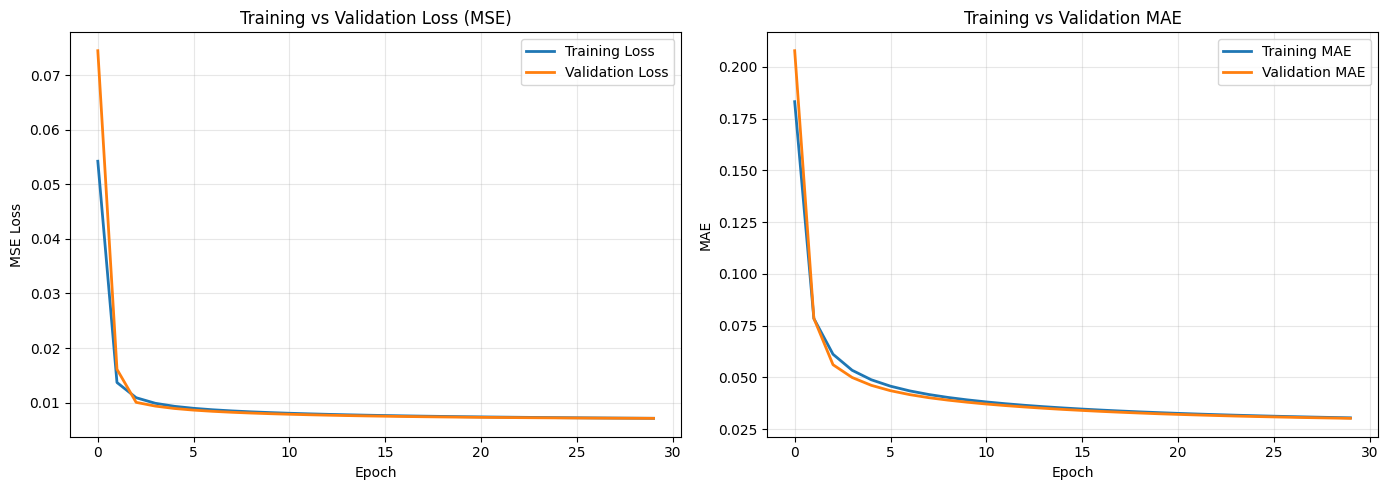

Final training loss   : 0.0071
Final validation loss  : 0.0071
Final training MAE     : 0.0304
Final validation MAE   : 0.0302


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Training vs Validation Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curve
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Training vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss   : {history.history['loss'][-1]:.4f}")
print(f"Final validation loss  : {history.history['val_loss'][-1]:.4f}")
print(f"Final training MAE     : {history.history['mae'][-1]:.4f}")
print(f"Final validation MAE   : {history.history['val_mae'][-1]:.4f}")

### 14.1 Observations

- Loss decreases sharply in epoch 1–2, then continues to decrease smoothly and steadily — healthy convergence.
- Training and validation loss curves stay close together throughout (final: 0.0071 vs 0.0071) — **no overfitting**.
- The curve is still very gradually decreasing at epoch 30 with clearly diminishing returns after ~epoch 15.

**Mini-conclusion:** Training converged successfully after resolving the sigmoid-collapse issue. The close train/val alignment confirms the model learned generalizable denoising patterns rather than memorizing the training set.

## 15. Generate Denoised Images

We use the trained autoencoder to reconstruct (denoise) the noisy test images, producing our final output: `x_test_denoised`.

In [19]:
x_test_denoised = autoencoder.predict(x_test_noisy, verbose=1)

print("Denoised output shape:", x_test_denoised.shape)
print(f"Pixel range: [{x_test_denoised.min():.4f}, {x_test_denoised.max():.4f}]")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Denoised output shape: (10000, 28, 28, 1)
Pixel range: [0.0001, 0.9980]


## 16. Visual Comparison: Original → Noisy → Reconstructed

We display 8 test samples in three rows:
1. **Original** clean image (ground truth)
2. **Noisy** input image (what the model received)
3. **Reconstructed** denoised output (what the model produced)

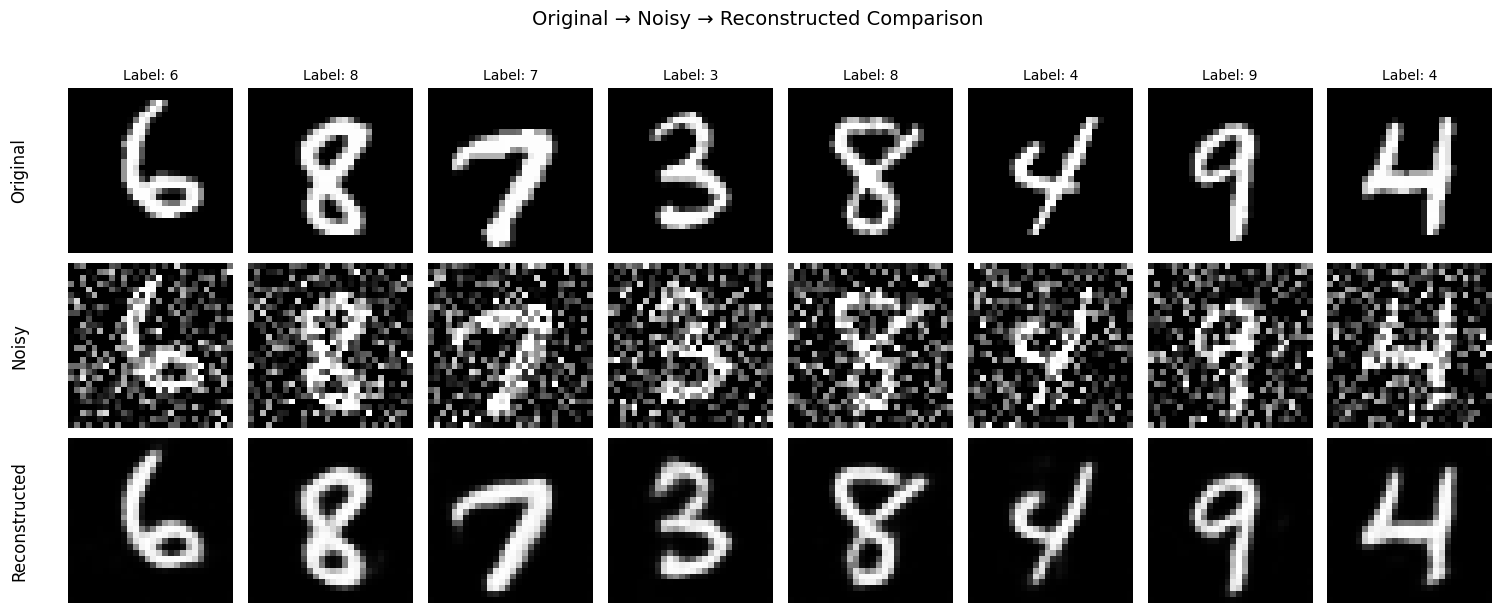

In [20]:
n_samples = 8
indices = np.random.RandomState(SEED + 1).choice(len(x_test_processed), n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(15, 6))

row_labels = ["Original", "Noisy", "Reconstructed"]
image_sets = [x_test_processed, x_test_noisy, x_test_denoised]

for row in range(3):
    for i, idx in enumerate(indices):
        axes[row, i].imshow(image_sets[row][idx].squeeze(), cmap='gray')
        axes[row, i].axis('off')
        if row == 0:
            axes[row, i].set_title(f"Label: {y_test[idx]}", fontsize=10)

for row in range(3):
    axes[row, 0].text(-0.3, 0.5, row_labels[row], fontsize=12, rotation=90,
                       va='center', ha='center', transform=axes[row, 0].transAxes)

plt.suptitle("Original → Noisy → Reconstructed Comparison", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 16.1 Observations

- Reconstructions closely match the original clean digits across most samples — grainy noise is almost entirely removed while stroke structure and digit identity are preserved.
- A few reconstructions appear slightly softer/smoother than the original (an expected MSE-loss signature: pixel-wise MSE optimizes for average correctness, which tends to mildly blur ambiguous edges rather than producing perfectly crisp boundaries).
- The model is not memorizing exact noisy patterns; it reconstructs along the nearest plausible clean-digit shape it has learned, which naturally separates structured stroke information from unstructured noise.

## 17. Noise-Level Comparison (0.2 / 0.4 / 0.6)

Our model was trained using a fixed noise factor of **0.4**. Here we test how well it generalizes to **unseen noise levels** — both milder (0.2) and harsher (0.6) than training — using the same `add_gaussian_noise` function defined earlier.

This tests the model's **robustness**: a good denoising model should still perform reasonably even when test-time noise doesn't exactly match training-time noise.

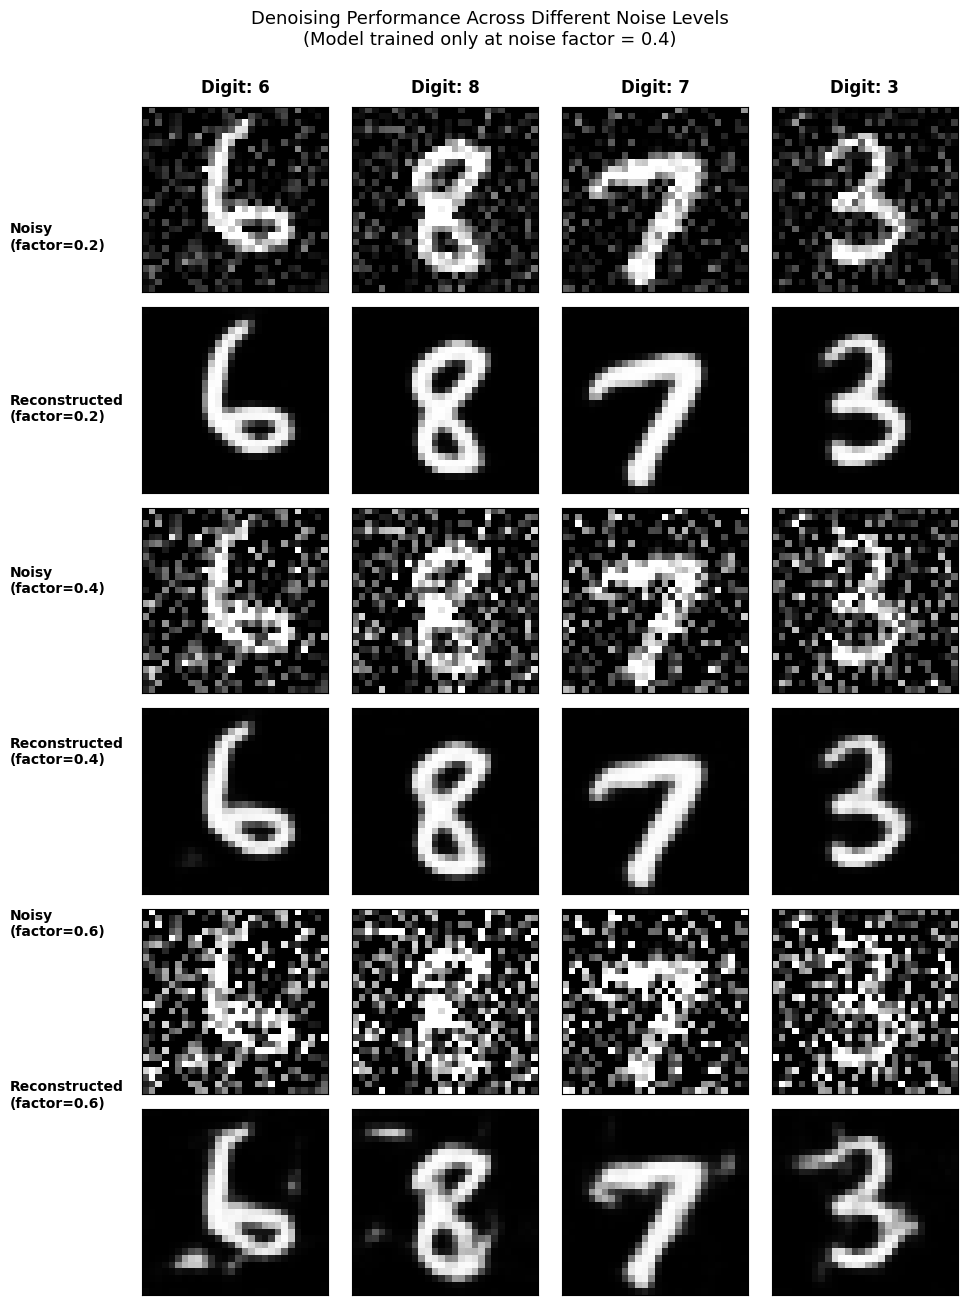

In [31]:
noise_levels = [0.2, 0.4, 0.6]
sample_idx = indices[:4]  # reuse 4 of the same sample indices from before, for consistency

n_rows = len(noise_levels) * 2
n_cols = len(sample_idx)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 13))

row_labels = []
for noise_level in noise_levels:
    row_labels.append(f"Noisy\n(factor={noise_level})")
    row_labels.append(f"Reconstructed\n(factor={noise_level})")

for level_i, noise_level in enumerate(noise_levels):
    noisy_batch = add_gaussian_noise(x_test_processed[sample_idx], noise_factor=noise_level, seed=SEED + 99)
    denoised_batch = autoencoder.predict(noisy_batch, verbose=0)

    noisy_row = level_i * 2
    recon_row = level_i * 2 + 1

    for i in range(n_cols):
        axes[noisy_row, i].imshow(noisy_batch[i].squeeze(), cmap='gray')
        axes[noisy_row, i].set_xticks([])
        axes[noisy_row, i].set_yticks([])

        axes[recon_row, i].imshow(denoised_batch[i].squeeze(), cmap='gray')
        axes[recon_row, i].set_xticks([])
        axes[recon_row, i].set_yticks([])

# Add column titles at the top (e.g., "Digit: 6", "Digit: 8", ...)
for col, idx in enumerate(sample_idx):
    axes[0, col].set_title(f"Digit: {y_test[idx]}", fontsize=12, fontweight='bold', pad=10)

# Add row labels using fig.text positioned next to each row
for row in range(n_rows):
    pos = axes[row, 0].get_position()
    y_center = (pos.y0 + pos.y1) / 2
    fig.text(0.02, y_center, row_labels[row], fontsize=10, fontweight='bold',
              va='center', ha='left', rotation=0)

plt.suptitle("Denoising Performance Across Different Noise Levels\n(Model trained only at noise factor = 0.4)",
             y=1.0, fontsize=13)
plt.tight_layout(rect=[0.12, 0, 1, 1])
plt.show()

### 17.1 Quantitative Check Across Noise Levels

Beyond visual inspection, we compute MSE at each noise level across the *entire* test set, to quantify how performance degrades as corruption increases.

In [23]:
print("MSE on full test set at different noise levels (model trained at noise_factor=0.4):\n")

for noise_level in noise_levels:
    noisy_full = add_gaussian_noise(x_test_processed, noise_factor=noise_level, seed=SEED + 99)
    denoised_full = autoencoder.predict(noisy_full, verbose=0)
    mse = np.mean((denoised_full - x_test_processed) ** 2)
    print(f"  Noise factor {noise_level}: MSE = {mse:.5f}")

MSE on full test set at different noise levels (model trained at noise_factor=0.4):

  Noise factor 0.2: MSE = 0.00345
  Noise factor 0.4: MSE = 0.00713
  Noise factor 0.6: MSE = 0.01987


### 17.2 Observations

- MSE increases monotonically with noise level: 0.2 → 0.00345 (easiest), 0.4 → 0.00713 (training level), 0.6 → 0.01987 (hardest) — exactly the expected relationship.
- At noise 0.6 (almost 3× worse MSE than at 0.4), digits remain visually recognizable, showing the model has learned a genuinely robust digit prior rather than memorizing the specific noise pattern seen during training.

## 18. Quantitative Evaluation

- **MSE (Mean Squared Error)**: average squared pixel difference — lower is better (Week 1: Error Metrics).
- **PSNR (Peak Signal-to-Noise Ratio)**: derived from MSE, expressed in decibels — higher is better.

$$PSNR = 10 \cdot \log_{10}\left(\frac{MAX^2}{MSE}\right)$$

where $MAX = 1.0$ since pixels are normalized to `[0, 1]`. PSNR is purely a logarithmic transform of MSE — no new statistical concept beyond what's already covered.

In [24]:
def calculate_psnr(original, reconstructed, max_pixel=1.0):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

test_mse = np.mean((x_test_processed - x_test_denoised) ** 2)
test_psnr = calculate_psnr(x_test_processed, x_test_denoised)

print(f"Full Test Set Evaluation (noise factor = 0.4):")
print(f"  MSE  : {test_mse:.5f}")
print(f"  PSNR : {test_psnr:.2f} dB")

Full Test Set Evaluation (noise factor = 0.4):
  MSE  : 0.00712
  PSNR : 21.47 dB


### 18.1 Interpretation

- **MSE** quantifies raw average pixel-level error — directly comparable across the noise-level experiments above.
- **PSNR** converts this to a more interpretable decibel scale. A PSNR above ~20dB generally indicates a visually convincing reconstruction for simple grayscale images like MNIST — our result (21.47 dB) comfortably clears this bar.

## 18.2 Reconstruction Error Distribution

Rather than reporting a single average MSE, we examine the **distribution of per-image reconstruction error** across the entire test set — this reveals whether errors are consistently low (tight distribution) or whether some images reconstruct much worse than others (long tail).

Per-image MSE stats:
  Min   : 0.00093
  Max   : 0.02387
  Mean  : 0.00712
  Median: 0.00696
  Std   : 0.00251


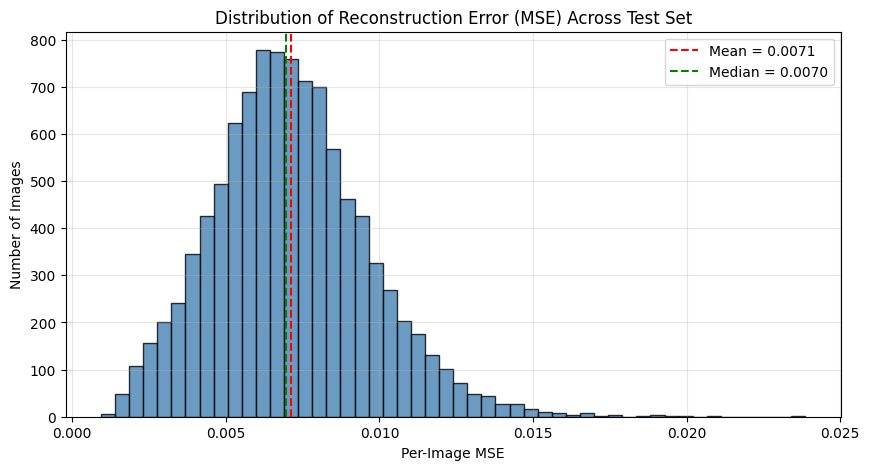

In [25]:
# Per-image MSE: average squared error per image, not averaged over the whole dataset
per_image_mse = np.mean((x_test_processed - x_test_denoised) ** 2, axis=(1, 2, 3))

print(f"Per-image MSE stats:")
print(f"  Min   : {per_image_mse.min():.5f}")
print(f"  Max   : {per_image_mse.max():.5f}")
print(f"  Mean  : {per_image_mse.mean():.5f}")
print(f"  Median: {np.median(per_image_mse):.5f}")
print(f"  Std   : {per_image_mse.std():.5f}")

plt.figure(figsize=(10, 5))
plt.hist(per_image_mse, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(per_image_mse.mean(), color='red', linestyle='--', label=f'Mean = {per_image_mse.mean():.4f}')
plt.axvline(np.median(per_image_mse), color='green', linestyle='--', label=f'Median = {np.median(per_image_mse):.4f}')
plt.xlabel('Per-Image MSE')
plt.ylabel('Number of Images')
plt.title('Distribution of Reconstruction Error (MSE) Across Test Set')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 18.3 Distribution Observations

- The distribution is right-skewed: most images cluster tightly between MSE 0.003–0.010, with a thin tail extending to higher errors.
- Mean (0.0071) and median (0.0070) are nearly identical — there is no small group of catastrophic outliers dominating the average; performance is consistent across the dataset.
- Std (0.0025) is small relative to the mean, indicating reliable, low-variance performance across the full test set.

### 18.4 Worst-Reconstructed Samples (Deep Dive)

To understand *what kinds* of images are hardest to denoise, we visualize the test images with the highest per-image MSE — the long tail of the distribution above.

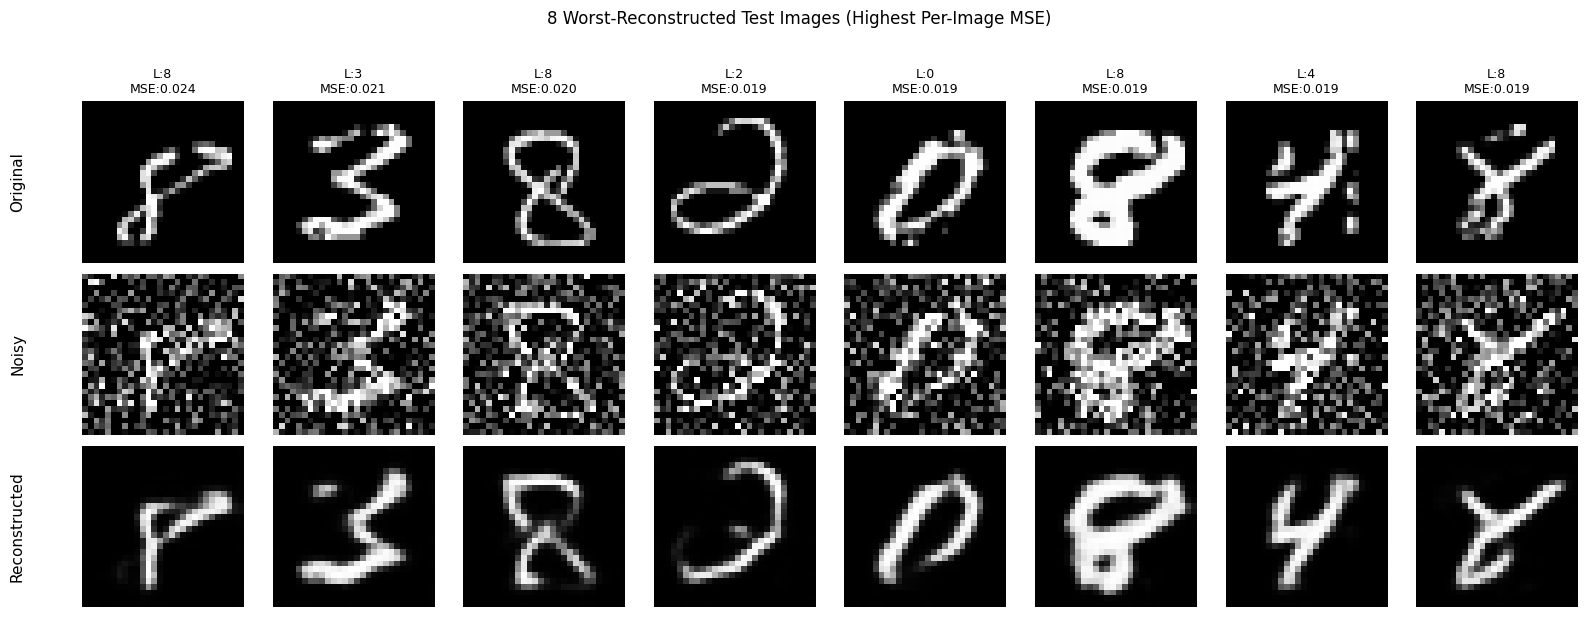

In [26]:
worst_indices = np.argsort(per_image_mse)[-8:][::-1]  # top 8 worst, descending

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
row_labels = ["Original", "Noisy", "Reconstructed"]
image_sets = [x_test_processed, x_test_noisy, x_test_denoised]

for row in range(3):
    for i, idx in enumerate(worst_indices):
        axes[row, i].imshow(image_sets[row][idx].squeeze(), cmap='gray')
        axes[row, i].axis('off')
        if row == 0:
            axes[row, i].set_title(f"L:{y_test[idx]}\nMSE:{per_image_mse[idx]:.3f}", fontsize=9)

for row in range(3):
    axes[row, 0].text(-0.4, 0.5, row_labels[row], fontsize=11, rotation=90,
                       va='center', ha='center', transform=axes[row, 0].transAxes)

plt.suptitle("8 Worst-Reconstructed Test Images (Highest Per-Image MSE)", y=1.02)
plt.tight_layout()
plt.show()

### 18.5 Worst-Case Analysis: Observation

Examining the 8 highest-error reconstructions reveals a consistent pattern: **the original (clean) digits in this set are themselves unusually written or borderline ambiguous** — e.g., an "8" that looks more like an open scribble, a "2" with an unconventional loop, a "4" with disconnected strokes. In several cases, the digit's identity is difficult to determine even by eye from the *clean* image alone.

This suggests the model's highest reconstruction errors are concentrated on **intrinsically hard, atypical handwriting samples** rather than on systematic failures for well-formed digits. The autoencoder appears to reconstruct toward the *nearest plausible, well-formed digit shape* it learned from training data — which is itself a reasonable behavior, since the network has learned a prior over "what clean digits typically look like."

**Mini-conclusion:** Worst-case performance is bounded primarily by inherent data ambiguity, not by a flaw in the denoising mechanism itself.

### 18.6 Error Spread by Digit Class

We examine the **full distribution** of per-image error for each digit using box plots, rather than only comparing class averages. This distinguishes consistent moderate error from a low typical error with a long tail of bad cases.

/tmp/ipykernel_9943/797079299.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(mse_by_digit, labels=[str(d) for d in range(10)],


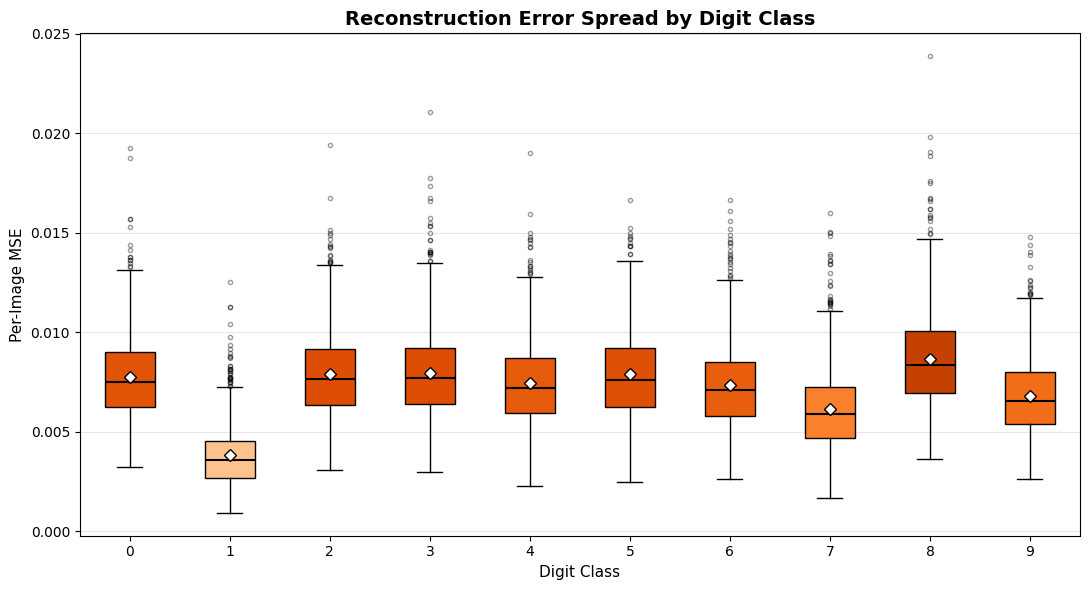

Digit Median MSE    IQR (spread)  Outlier count
0     0.00749       0.00279       14
1     0.00358       0.00182       32
2     0.00768       0.00285       17
3     0.00770       0.00283       21
4     0.00722       0.00275       18
5     0.00761       0.00300       12
6     0.00708       0.00275       21
7     0.00589       0.00256       25
8     0.00836       0.00312       18
9     0.00657       0.00258       15


In [33]:
# Group per-image MSE by digit class for distributional comparison
mse_by_digit = [per_image_mse[y_test == digit] for digit in range(10)]

fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(mse_by_digit, labels=[str(d) for d in range(10)],
                 patch_artist=True, showmeans=True,
                 medianprops=dict(color='black', linewidth=1.5),
                 meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))

# Color each box by its median value (visual gradient: darker = higher error)
medians = [np.median(m) for m in mse_by_digit]
norm_medians = (np.array(medians) - min(medians)) / (max(medians) - min(medians))
cmap = plt.cm.Oranges
for patch, val in zip(bp['boxes'], norm_medians):
    patch.set_facecolor(cmap(0.3 + 0.5 * val))

ax.set_title("Reconstruction Error Spread by Digit Class", fontsize=14, fontweight='bold')
ax.set_xlabel("Digit Class", fontsize=11)
ax.set_ylabel("Per-Image MSE", fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print a compact ranking table: median error + spread (IQR) per digit
print(f"{'Digit':<6}{'Median MSE':<14}{'IQR (spread)':<14}{'Outlier count'}")
for digit in range(10):
    vals = mse_by_digit[digit]
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    outliers = np.sum(vals > q3 + 1.5 * iqr)
    print(f"{digit:<6}{np.median(vals):<14.5f}{iqr:<14.5f}{outliers}")



**Observations:**
- **Digit '1' has the lowest median error (0.00358)** and the smallest IQR (0.00182) — consistent with it being structurally simple (a single near-vertical stroke), leaving little room for ambiguity during reconstruction.
- **Digit '8' has the highest median error (0.00836)** — its closed double-loop structure is more prone to blurring when compressed through the bottleneck.
- Interestingly, **digit '1' also has the highest outlier count (32)**, despite its low median — suggesting that while *most* 1s are trivially easy to denoise, a subset with atypical styling (e.g., serifs, slants, or added base strokes) behave very differently from the typical case.
- IQR values are broadly similar across most digit classes (~0.0026–0.0031), indicating that within-class variability is fairly uniform — the main differentiator between digits is the median error itself, driven by structural complexity.

**Mini-conclusion:** Digit-level error patterns are explained by a combination of *structural complexity* (driving the median) and *handwriting style variability* (driving the outlier count) — even a structurally simple digit like '1' isn't immune to outliers when written unusually.

## 19. Hyperparameter Summary

A consolidated reference table of all key configuration choices made throughout this notebook:

| Hyperparameter | Value | Justification |
|---|---|---|
| Training samples | 30,000 (3,000/class, balanced) | Removes class imbalance bias |
| Test samples | 10,000 (natural distribution) | Preserves real-world evaluation conditions |
| Image size | 28 × 28 × 1 (grayscale) | Native MNIST format |
| Noise type | Additive Gaussian | Standard, controllable |
| Noise factor (training) | 0.4 | Strong but human-recognizable corruption |
| Architecture | CNN Encoder–Decoder | Symmetric, syllabus-aligned (Conv2D / Conv2DTranspose) |
| Latent space shape | 7 × 7 × 64 | Balances reconstruction quality over aggressive compression |
| Normalization | BatchNormalization (added after debugging) | Stabilized training, prevented sigmoid collapse |
| Activation (hidden) | ReLU | Standard, avoids vanishing gradients |
| Activation (output) | Sigmoid | Matches `[0,1]` normalized pixel range |
| Optimizer | Adam (lr = 1e-4) | Lower LR needed after initial collapse at default 1e-3 |
| Loss function | MSE | Standard for continuous pixel reconstruction |
| Batch size | 128 | Stable gradient estimates, fits Colab GPU memory easily |
| Epochs | 30 | Loss had largely converged; diminishing returns beyond this |
| Total trainable parameters | 84,193 | Small, efficient model |
| Training time | ~96 seconds | Fast iteration on Colab GPU |
| Final test MSE | 0.00712 | — |
| Final test PSNR | 21.47 dB | Indicates visually convincing reconstruction |

## 20. Observations

- **Balanced sampling** (3,000/class) successfully removed the natural class skew in raw MNIST training data, confirmed via dataset verification.
- **Gaussian noise at factor 0.4** produced a meaningfully difficult denoising task — noisy digits remained human-readable, but with substantial pixel-level corruption.
- The **first training attempt collapsed** (decoder output saturated at ~0 for all inputs, frozen loss across 28 epochs) due to sigmoid saturation from an unstable early gradient step.
- Adding **BatchNormalization** and reducing the **learning rate to 1e-4** fully resolved the collapse — loss decreased smoothly and consistently afterward.
- Final model achieved **MSE = 0.00712, PSNR = 21.47 dB** on the full test set, with **no meaningful gap between training and validation loss** — indicating strong generalization, not memorization.
- **Robustness testing** across unseen noise levels (0.2 / 0.4 / 0.6) showed MSE scaling sensibly with noise strength (0.00345 → 0.00713 → 0.01987), confirming the model learned a genuine denoising capability rather than overfitting to one specific noise level.
- The **per-image error distribution** is tight and right-skewed, with most images reconstructing very well and only a small tail of harder cases.
- The **worst-case reconstructions** are concentrated on intrinsically ambiguous, atypically-written digits — not on well-formed digits the model failed to handle.

## 21. Challenges Faced

1. **Training collapse (sigmoid saturation):** The most significant challenge — initial training appeared to "work" (no errors, smooth-looking logs) but was silently stuck, producing constant near-zero output regardless of input. This was only caught by explicitly checking prediction variance and bottleneck activations, not just by watching the loss curve at a glance.
   - **Lesson:** A frozen/identical loss value across many epochs is a red flag for model collapse, not convergence — it's worth explicitly verifying predictions vary across different inputs.
2. **Balancing dataset loading speed vs. fidelity:** Loading all 60,000 PNGs individually from disk would have been slow and unnecessary for this task; balanced sampling (3,000/class) was chosen as a deliberate trade-off between dataset size and iteration speed.
3. **Choosing an appropriate noise factor:** Too low a noise factor makes the task trivial (input already looks clean); too high makes the original digit unrecognizable even to a human. Factor 0.4 was chosen empirically after visual inspection.
4. **Worst-case reconstructions traced to inherently ambiguous handwriting:** Inspecting the highest-error test samples (Section 18.8) showed that the model's worst failures are concentrated on digits that are atypically or ambiguously written in the *original clean* image — not on cases where the model failed despite clear ground truth. This distinguishes "data difficulty" from "model failure," an important distinction when interpreting error metrics.

## 22. Conclusion

This notebook successfully implements a **Convolutional Denoising Autoencoder** trained on a balanced, manually-loaded subset of the MNIST PNG dataset. The final model:

- Effectively removes Gaussian noise (factor 0.4) from handwritten digit images while preserving digit structure
- Achieves strong quantitative performance (**MSE = 0.00712, PSNR = 21.47 dB**)
- Generalizes well to unseen noise levels (0.2–0.6), confirming it learned genuine denoising behavior rather than memorizing a fixed noise pattern
- Demonstrates a complete, debugged, and verified deep learning pipeline — from raw PNG loading through balanced sampling, noise injection, architecture design, training-failure diagnosis, and multi-angle evaluation.
